In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)



# Load the dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/nudratabbas/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10000, 20)

First 5 rows:


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


# Data Summary

In [4]:
def initial_inspection(df):
   

    line = "=" * 80
    box = lambda title: print(f"\n{line}\n {title}\n{line}")

    # DATASET INFO 
    box("DATASET INFO")

    print(f"Total records   : {len(df):,}")
    print(f"Total features  : {len(df.columns)}")

    #  DATA TYPES =
    box("DATA TYPES")

    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"{str(dtype):<20} : {count} columns")

    #  MISSING VALUES 
    box("MISSING VALUES")

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        "Missing_Count": missing,
        "Missing_Percentage": missing_pct
    }).sort_values("Missing_Count", ascending=False)

    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    if len(missing_df) > 0:
        print(missing_df)
    else:
        print(" No missing values found!")

    #  TARGET DISTRIBUTION 
    box("TARGET VARIABLE DISTRIBUTION (Is_Fraud)")

    fraud_counts = df["Is_Fraud"].value_counts()
    fraud_pct = df["Is_Fraud"].value_counts(normalize=True) * 100

    print(f"{'Legitimate (0)':<20} : {fraud_counts[0]:,} ({fraud_pct[0]:.2f}%)")
    print(f"{'Fraudulent (1)':<20} : {fraud_counts[1]:,} ({fraud_pct[1]:.2f}%)")

    # NUMERIC SUMMARY
    box("NUMERIC COLUMNS SUMMARY")

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "Is_Fraud" in numeric_cols:
        numeric_cols.remove("Is_Fraud")

    print(df[numeric_cols].describe().T)

    #  CATEGORICAL INFO 
    box("CATEGORICAL COLUMNS")

    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

    for col in categorical_cols:
        print(f"\n {col}")
        print(f"Unique values: {df[col].nunique():,}")

        if df[col].nunique() <= 10:
            print(f"Values: {df[col].unique().tolist()}")

    return numeric_cols, categorical_cols


numeric_cols, categorical_cols = initial_inspection(df)


 DATASET INFO
Total records   : 10,000
Total features  : 20

 DATA TYPES
object               : 10 columns
int64                : 7 columns
float64              : 3 columns

 MISSING VALUES
                    Missing_Count  Missing_Percentage
Provider_Specialty            350                 3.5
Prior_Visits_12m              350                 3.5
Insurance_Type                350                 3.5

 TARGET VARIABLE DISTRIBUTION (Is_Fraud)
Legitimate (0)       : 9,171 (91.71%)
Fraudulent (1)       : 829 (8.29%)

 NUMERIC COLUMNS SUMMARY
                                         count          mean           std  \
Patient_Age                            10000.0     49.755000     17.910144   
Procedure_Code                         10000.0  86905.211700  14965.324960   
Claim_Amount                           10000.0    572.804406    406.202437   
Approved_Amount                        10000.0    475.514157    323.257165   
Days_Between_Service_and_Claim         10000.0     14.413800  

In [5]:
def perform_eda(df, numeric_cols, categorical_cols):
    

    line = "=" * 90
    box = lambda title: print(f"\n{line}\n {title}\n{line}")

    # RAUD VS LEGIT
    box("FRAUD VS LEGITIMATE CLAIMS ANALYSIS")

    fraud_comparison = []

    for col in numeric_cols:
        if col != "Is_Fraud":
            legit_mean = df[df["Is_Fraud"] == 0][col].mean()
            fraud_mean = df[df["Is_Fraud"] == 1][col].mean()
            diff_pct = ((fraud_mean - legit_mean) / legit_mean) * 100 if legit_mean != 0 else 0

            fraud_comparison.append({
                "Feature": col,
                "Legit_Mean": legit_mean,
                "Fraud_Mean": fraud_mean,
                "Diff_%": diff_pct
            })

    fraud_comp_df = pd.DataFrame(fraud_comparison)

    fraud_comp_df = fraud_comp_df.sort_values(
        "Diff_%", key=lambda x: x.abs(), ascending=False
    )

    print("\n Feature-wise Difference (Fraud vs Legit):\n")
    print(fraud_comp_df.to_string(index=False))

    # Business insight
    claim_legit = df[df["Is_Fraud"] == 0]["Claim_Amount"].mean()
    claim_fraud = df[df["Is_Fraud"] == 1]["Claim_Amount"].mean()

    box("BUSINESS INSIGHT")

    print(
        f"Fraudulent claims are on average "
        f"{((claim_fraud - claim_legit) / claim_legit) * 100:.2f}% higher than legitimate claims"
    )

    #  PROVIDER ANALYSIS 
    box("PROVIDER FRAUD ANALYSIS")

    provider_fraud = (
        df.groupby("Provider_ID")["Is_Fraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Claims",
            "sum": "Fraud_Count",
            "mean": "Fraud_Rate"
        })
        .sort_values("Fraud_Count", ascending=False)
    )

    print("\n Top 10 Providers by Fraud Count:\n")
    print(provider_fraud.head(10).to_string())

    #  SPECIALTY 
    box("PROVIDER SPECIALTY FRAUD RATES")

    specialty_fraud = (
        df.groupby("Provider_Specialty")["Is_Fraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Claims",
            "sum": "Fraud_Count",
            "mean": "Fraud_Rate"
        })
        .sort_values("Fraud_Rate", ascending=False)
    )

    print("\n Top 10 Specialties by Fraud Rate:\n")
    print(specialty_fraud.head(10).to_string())

    # INSURANCE TYPE 
    box("INSURANCE TYPE FRAUD ANALYSIS")

    insurance_fraud = (
        df.groupby("Insurance_Type")["Is_Fraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Claims",
            "sum": "Fraud_Count",
            "mean": "Fraud_Rate"
        })
        .sort_values("Fraud_Rate", ascending=False)
    )

    print(insurance_fraud.to_string())

    #  VISIT TYPE 
    box("VISIT TYPE FRAUD ANALYSIS")

    visit_fraud = (
        df.groupby("Visit_Type")["Is_Fraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Claims",
            "sum": "Fraud_Count",
            "mean": "Fraud_Rate"
        })
        .sort_values("Fraud_Rate", ascending=False)
    )

    print(visit_fraud.to_string())

    # CLAIM STATUS 
    box("CLAIM STATUS FRAUD ANALYSIS")

    status_fraud = (
        df.groupby("Claim_Status")["Is_Fraud"]
        .agg(["count", "sum", "mean"])
        .rename(columns={
            "count": "Total_Claims",
            "sum": "Fraud_Count",
            "mean": "Fraud_Rate"
        })
        .sort_values("Fraud_Rate", ascending=False)
    )

    print(status_fraud.to_string())

    # CORRELATION 
    box("CORRELATION WITH FRAUD")

    correlations = df[numeric_cols + ["Is_Fraud"]].corr()["Is_Fraud"].sort_values(ascending=False)

    print("\n Feature Correlation with Fraud:\n")
    print(correlations.to_string())

    return fraud_comp_df, provider_fraud, specialty_fraud


fraud_comp_df, provider_fraud, specialty_fraud = perform_eda(df, numeric_cols, categorical_cols)


 FRAUD VS LEGITIMATE CLAIMS ANALYSIS

 Feature-wise Difference (Fraud vs Legit):

                              Feature   Legit_Mean   Fraud_Mean     Diff_%
                         Claim_Amount   535.008352   990.931797  85.218005
       Days_Between_Service_and_Claim    15.447825     2.974668 -80.743772
                      Approved_Amount   469.154258   545.871978  16.352344
Number_of_Claims_Per_Provider_Monthly    68.016901    75.388420  10.837775
               Chronic_Condition_Flag     0.290808     0.305187   4.944497
                          Patient_Age    49.846036    48.747889  -2.203079
                       Length_of_Stay     2.200087     2.190591  -0.431626
                       Procedure_Code 86889.657071 87077.288299   0.215942
                     Prior_Visits_12m     3.026102     3.030000   0.128823

 BUSINESS INSIGHT
Fraudulent claims are on average 85.22% higher than legitimate claims

 PROVIDER FRAUD ANALYSIS

 Top 10 Providers by Fraud Count:

             Tot

# FEATURE ENGINEERING 

In [6]:
def create_base_features(df):
  
    
    
 
    
    df_fe = df.copy()
    
    #  Temporal Features
    print("\n Creating Temporal Features...")
    df_fe['Claim_Submission_Date'] = pd.to_datetime(df_fe['Claim_Submission_Date'])
    df_fe['Submission_Year'] = df_fe['Claim_Submission_Date'].dt.year
    df_fe['Submission_Month'] = df_fe['Claim_Submission_Date'].dt.month
    df_fe['Submission_DayOfWeek'] = df_fe['Claim_Submission_Date'].dt.dayofweek
    df_fe['Submission_Quarter'] = df_fe['Claim_Submission_Date'].dt.quarter
    df_fe['Weekend_Submission'] = df_fe['Submission_DayOfWeek'].isin([5,6]).astype(int)
    
    #  Ratio Features
    print("\n Creating Ratio Features...")
    df_fe['Claim_Approved_Ratio'] = df_fe['Claim_Amount'] / (df_fe['Approved_Amount'] + 1)
    df_fe['Days_Between_Normalized'] = df_fe['Days_Between_Service_and_Claim'] / 30
    df_fe['Claim_Deviation'] = df_fe['Claim_Amount'] - df_fe['Approved_Amount']
    
    # Patient Risk Features
    print("\n Creating Patient Risk Features...")
    df_fe['Age_Group'] = pd.cut(df_fe['Patient_Age'], 
                                 bins=[0, 18, 30, 50, 65, 100], 
                                 labels=['Child', 'Young_Adult', 'Adult', 'Senior', 'Elderly'])
    
    df_fe['High_Risk_Combination'] = (
        (df_fe['Claim_Amount'] > df_fe['Claim_Amount'].quantile(0.95)) & 
        (df_fe['Days_Between_Service_and_Claim'] < df_fe['Days_Between_Service_and_Claim'].quantile(0.1))
    ).astype(int)
    
    df_fe['Visits_Per_Age'] = df_fe['Prior_Visits_12m'] / (df_fe['Patient_Age'] + 1)
    
    #  Interaction Features
    print("\n Creating Interaction Features...")
    df_fe['Amount_Per_Day'] = df_fe['Claim_Amount'] / (df_fe['Length_of_Stay'] + 1)
    df_fe['Claim_Spike'] = (df_fe['Number_of_Claims_Per_Provider_Monthly'] > 
                            df_fe['Number_of_Claims_Per_Provider_Monthly'].quantile(0.95)).astype(int)
    
    # Frequency Encoding for High Cardinality 
    print("\n Creating Frequency Encodings")
    high_card_cols = ['Provider_ID', 'Diagnosis_Code', 'Procedure_Code']
    
    for col in high_card_cols:
        freq_encoding = df_fe[col].value_counts().to_dict()
        df_fe[f'{col}_Freq'] = df_fe[col].map(freq_encoding)
    
    #  One-hot encoding for low-cardinality columns
    print("\n Encoding Categorical Variables")
    low_card_cols = ['Patient_Gender', 'Insurance_Type', 'Provider_Specialty', 
                     'Patient_State', 'Claim_Status', 'Visit_Type']
    
    df_fe = pd.get_dummies(df_fe, columns=low_card_cols, drop_first=True)
    
   
    print(f"Original features: {df.shape[1]}")
    print(f"Features after engineering: {df_fe.shape[1]}")
    print(f"New features created: {df_fe.shape[1] - df.shape[1]}")
 
    
    return df_fe

df_engineered = create_base_features(df)


 Creating Temporal Features...

 Creating Ratio Features...

 Creating Patient Risk Features...

 Creating Interaction Features...

 Creating Frequency Encodings

 Encoding Categorical Variables
Original features: 20
Features after engineering: 50
New features created: 30


# EDA

In [7]:


df_viz = df.copy()

print(" Visualization data prepared")
print(f"Dataset shape: {df_viz.shape}")
print(f"Fraud cases: {df_viz['Is_Fraud'].sum():,}")
print(f"Legitimate cases: {(df_viz['Is_Fraud'] == 0).sum():,}")

 Visualization data prepared
Dataset shape: (10000, 20)
Fraud cases: 829
Legitimate cases: 9,171


## Fraud Distribution

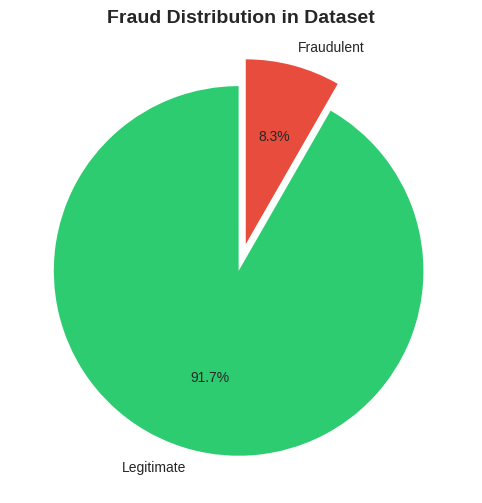


 Statistics:
Legitimate claims: 9,171 (91.7%)
Fraudulent claims: 829 (8.3%)


In [8]:

plt.figure(figsize=(8, 6))
fraud_counts = df_viz['Is_Fraud'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(fraud_counts, labels=['Legitimate', 'Fraudulent'], autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0.1))
plt.title('Fraud Distribution in Dataset', fontsize=14, fontweight='bold')
plt.show()

print(f"\n Statistics:")
print(f"Legitimate claims: {fraud_counts[0]:,} ({fraud_counts[0]/len(df_viz)*100:.1f}%)")
print(f"Fraudulent claims: {fraud_counts[1]:,} ({fraud_counts[1]/len(df_viz)*100:.1f}%)")

##  Claim Amount Distribution by Fraud Status

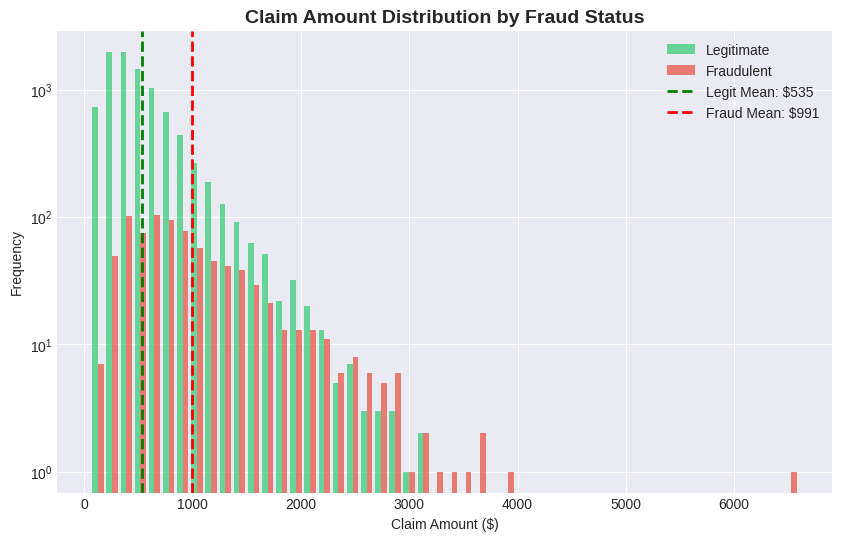


 Financial Insight:
Average legitimate claim: $535.01
Average fraudulent claim: $990.93
Difference: $455.92 (85.2% higher)


In [9]:

plt.figure(figsize=(10, 6))

fraud_0 = df_viz[df_viz['Is_Fraud'] == 0]['Claim_Amount']
fraud_1 = df_viz[df_viz['Is_Fraud'] == 1]['Claim_Amount']
legit_mean = fraud_0.mean()
fraud_mean = fraud_1.mean()

plt.hist([fraud_0, fraud_1], bins=50, alpha=0.7, label=['Legitimate', 'Fraudulent'], 
         color=['#2ecc71', '#e74c3c'])
plt.axvline(legit_mean, color='green', linestyle='--', linewidth=2, label=f'Legit Mean: ${legit_mean:.0f}')
plt.axvline(fraud_mean, color='red', linestyle='--', linewidth=2, label=f'Fraud Mean: ${fraud_mean:.0f}')
plt.xlabel('Claim Amount ($)')
plt.ylabel('Frequency')
plt.title('Claim Amount Distribution by Fraud Status', fontsize=14, fontweight='bold')
plt.legend()
plt.yscale('log')
plt.show()

print(f"\n Financial Insight:")
print(f"Average legitimate claim: ${legit_mean:,.2f}")
print(f"Average fraudulent claim: ${fraud_mean:,.2f}")
print(f"Difference: ${fraud_mean - legit_mean:,.2f} ({(fraud_mean/legit_mean - 1)*100:.1f}% higher)")

## Days Between Service and Claim

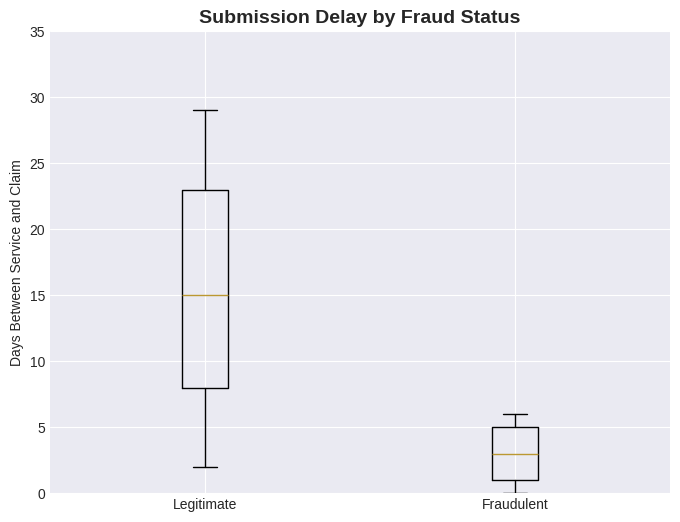


 Timing Analysis:
Legitimate claims - Mean delay: 15.4 days, Median: 15.0 days
Fraudulent claims - Mean delay: 3.0 days, Median: 3.0 days
Fraudulent claims submitted 12.5 days faster on average


In [10]:

plt.figure(figsize=(8, 6))

legit_delay = df_viz[df_viz['Is_Fraud'] == 0]['Days_Between_Service_and_Claim']
fraud_delay = df_viz[df_viz['Is_Fraud'] == 1]['Days_Between_Service_and_Claim']

plt.boxplot([legit_delay, fraud_delay], labels=['Legitimate', 'Fraudulent'])
plt.ylabel('Days Between Service and Claim')
plt.title('Submission Delay by Fraud Status', fontsize=14, fontweight='bold')
plt.ylim(0, 35)
plt.show()

print(f"\n Timing Analysis:")
print(f"Legitimate claims - Mean delay: {legit_delay.mean():.1f} days, Median: {legit_delay.median():.1f} days")
print(f"Fraudulent claims - Mean delay: {fraud_delay.mean():.1f} days, Median: {fraud_delay.median():.1f} days")
print(f"Fraudulent claims submitted {legit_delay.mean() - fraud_delay.mean():.1f} days faster on average")

##  Provider Fraud Rate Distribution

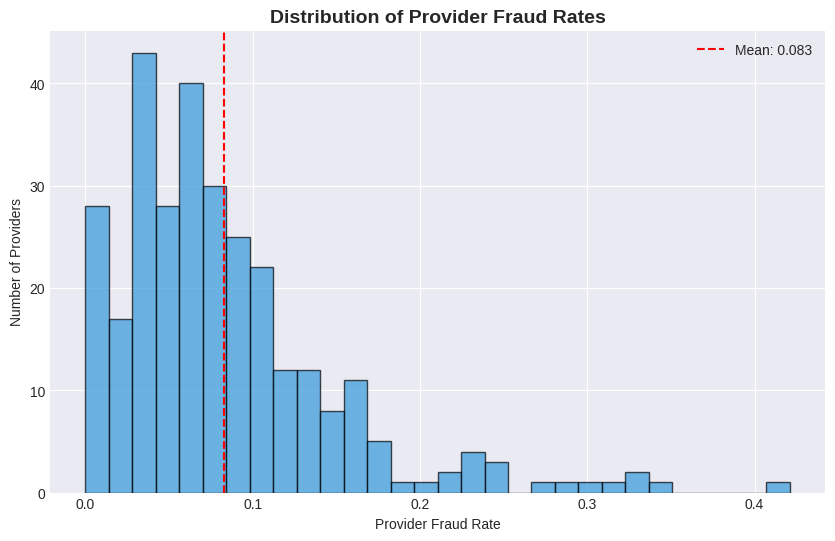


 Provider Risk Analysis:
Total providers: 300
Average fraud rate across providers: 8.27%
High-risk providers (>20% fraud rate): 18
Zero-risk providers (0% fraud rate): 28


In [11]:

plt.figure(figsize=(10, 6))

provider_fraud_rates = df_viz.groupby('Provider_ID')['Is_Fraud'].mean()
plt.hist(provider_fraud_rates, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
plt.xlabel('Provider Fraud Rate')
plt.ylabel('Number of Providers')
plt.title('Distribution of Provider Fraud Rates', fontsize=14, fontweight='bold')
plt.axvline(provider_fraud_rates.mean(), color='red', linestyle='--', label=f'Mean: {provider_fraud_rates.mean():.3f}')
plt.legend()
plt.show()

print(f"\n Provider Risk Analysis:")
print(f"Total providers: {len(provider_fraud_rates):,}")
print(f"Average fraud rate across providers: {provider_fraud_rates.mean():.2%}")
print(f"High-risk providers (>20% fraud rate): {(provider_fraud_rates > 0.2).sum()}")
print(f"Zero-risk providers (0% fraud rate): {(provider_fraud_rates == 0).sum()}")

##  Insurance Type Fraud Rates

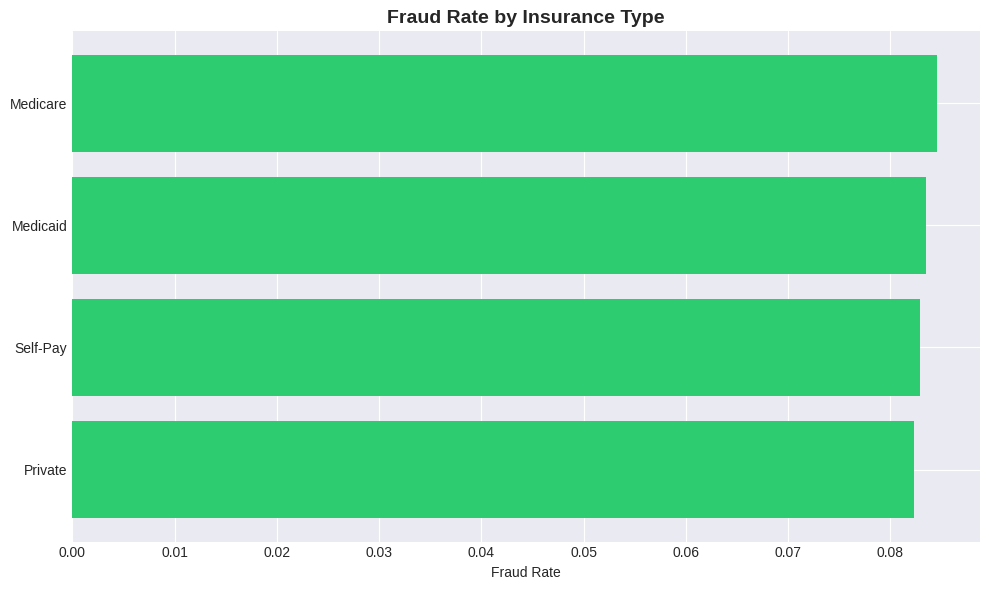


 Insurance Type Analysis:
Private: 8.23% fraud rate
Self-Pay: 8.29% fraud rate
Medicaid: 8.35% fraud rate
Medicare: 8.45% fraud rate


In [12]:

plt.figure(figsize=(10, 6))

insurance_fraud = df_viz.groupby('Insurance_Type')['Is_Fraud'].mean().sort_values()
colors_bar = ['#e74c3c' if x > 0.1 else '#2ecc71' for x in insurance_fraud.values]
plt.barh(range(len(insurance_fraud)), insurance_fraud.values, color=colors_bar)
plt.yticks(range(len(insurance_fraud)), insurance_fraud.index)
plt.xlabel('Fraud Rate')
plt.title('Fraud Rate by Insurance Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Insurance Type Analysis:")
for insurance, rate in insurance_fraud.items():
    print(f"{insurance}: {rate:.2%} fraud rate")

##  Provider Specialty Fraud Rates

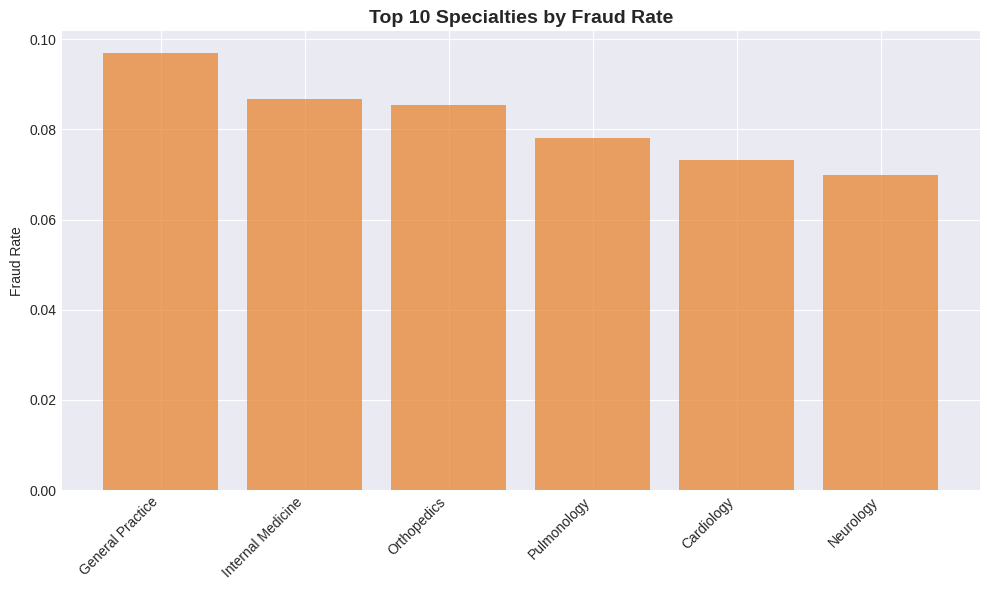


 Specialty Risk Analysis:
1. General Practice: 9.69% fraud rate
2. Internal Medicine: 8.67% fraud rate
3. Orthopedics: 8.54% fraud rate
4. Pulmonology: 7.81% fraud rate
5. Cardiology: 7.32% fraud rate
6. Neurology: 6.99% fraud rate


In [13]:

plt.figure(figsize=(10, 6))

specialty_fraud = df_viz.groupby('Provider_Specialty')['Is_Fraud'].mean().sort_values(ascending=False).head(10)
plt.bar(range(len(specialty_fraud)), specialty_fraud.values, color='#e67e22', alpha=0.7)
plt.xticks(range(len(specialty_fraud)), specialty_fraud.index, rotation=45, ha='right')
plt.ylabel('Fraud Rate')
plt.title('Top 10 Specialties by Fraud Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Specialty Risk Analysis:")
for i, (specialty, rate) in enumerate(specialty_fraud.items(), 1):
    print(f"{i}. {specialty}: {rate:.2%} fraud rate")

##  Age Distribution by Fraud Status

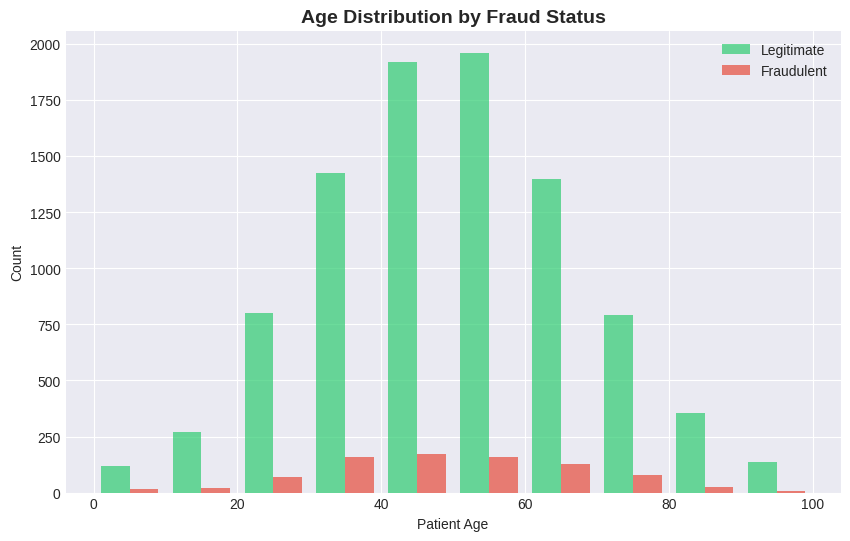


 Age Demographics:
Legitimate claims - Mean age: 49.8, Median: 50.0
Fraudulent claims - Mean age: 48.7, Median: 48.0


In [14]:

plt.figure(figsize=(10, 6))

age_bins = range(0, 101, 10)
age_legit = df_viz[df_viz['Is_Fraud'] == 0]['Patient_Age']
age_fraud = df_viz[df_viz['Is_Fraud'] == 1]['Patient_Age']
plt.hist([age_legit, age_fraud], bins=age_bins, alpha=0.7, label=['Legitimate', 'Fraudulent'],
         color=['#2ecc71', '#e74c3c'])
plt.xlabel('Patient Age')
plt.ylabel('Count')
plt.title('Age Distribution by Fraud Status', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

print(f"\n Age Demographics:")
print(f"Legitimate claims - Mean age: {age_legit.mean():.1f}, Median: {age_legit.median():.1f}")
print(f"Fraudulent claims - Mean age: {age_fraud.mean():.1f}, Median: {age_fraud.median():.1f}")

## Claim Amount vs Approved Amount

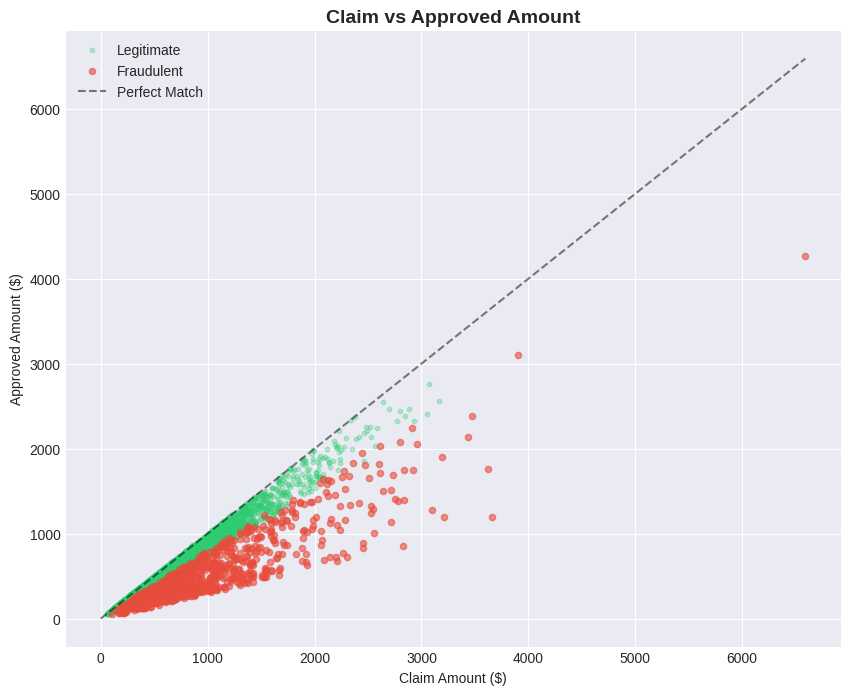


 Claim Approval Analysis:
Legitimate - Avg approval rate: 87.6%
Fraudulent - Avg approval rate: 54.7%


In [15]:

plt.figure(figsize=(10, 8))

plt.scatter(df_viz[df_viz['Is_Fraud'] == 0]['Claim_Amount'], 
            df_viz[df_viz['Is_Fraud'] == 0]['Approved_Amount'],
            alpha=0.3, c='#2ecc71', label='Legitimate', s=10)
plt.scatter(df_viz[df_viz['Is_Fraud'] == 1]['Claim_Amount'], 
            df_viz[df_viz['Is_Fraud'] == 1]['Approved_Amount'],
            alpha=0.6, c='#e74c3c', label='Fraudulent', s=20)
plt.plot([0, df_viz['Claim_Amount'].max()], [0, df_viz['Claim_Amount'].max()], 
         'k--', alpha=0.5, label='Perfect Match')
plt.xlabel('Claim Amount ($)')
plt.ylabel('Approved Amount ($)')
plt.title('Claim vs Approved Amount', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

print(f"\n Claim Approval Analysis:")
print(f"Legitimate - Avg approval rate: {(df_viz[df_viz['Is_Fraud'] == 0]['Approved_Amount'] / df_viz[df_viz['Is_Fraud'] == 0]['Claim_Amount']).mean():.1%}")
print(f"Fraudulent - Avg approval rate: {(df_viz[df_viz['Is_Fraud'] == 1]['Approved_Amount'] / df_viz[df_viz['Is_Fraud'] == 1]['Claim_Amount']).mean():.1%}")

## Correlation Heatmap

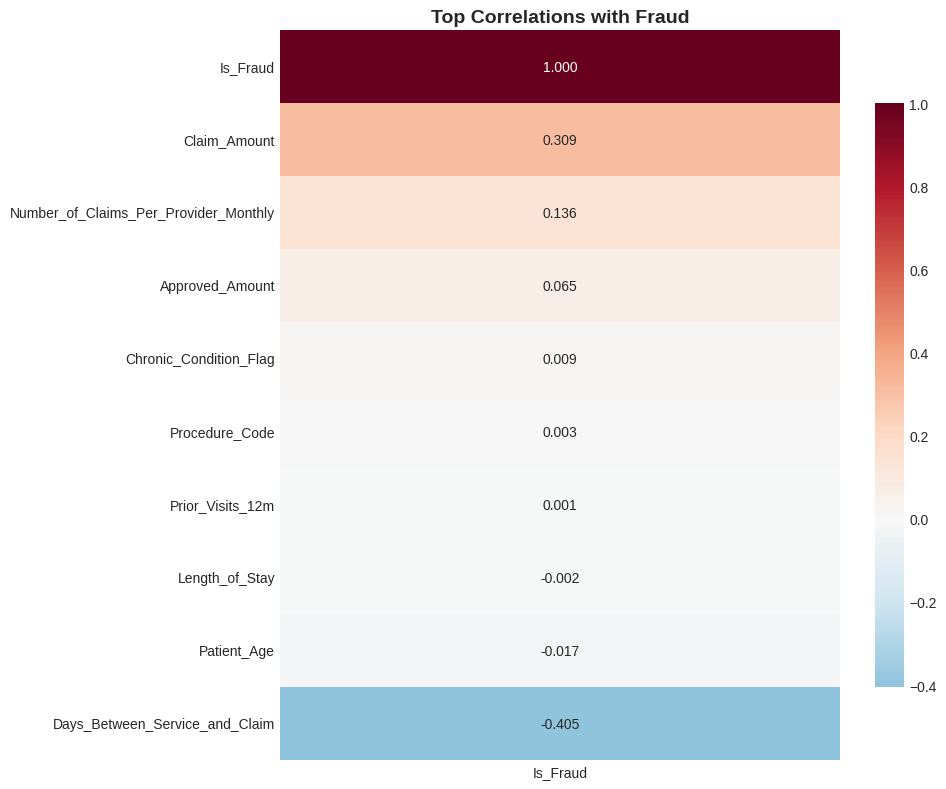


 Top 5 Features Correlated with Fraud:
1. Is_Fraud: 1.000
2. Claim_Amount: 0.309
3. Number_of_Claims_Per_Provider_Monthly: 0.136
4. Approved_Amount: 0.065
5. Chronic_Condition_Flag: 0.009


In [16]:

plt.figure(figsize=(10, 8))

numeric_corr = df_viz.select_dtypes(include=[np.number]).corr()
fraud_corr = numeric_corr['Is_Fraud'].sort_values(ascending=False).head(15)
fraud_corr_df = fraud_corr.to_frame()
sns.heatmap(fraud_corr_df, annot=True, cmap='RdBu_r', center=0, 
            fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Top Correlations with Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Top 5 Features Correlated with Fraud:")
for i, (feature, corr) in enumerate(fraud_corr.head(5).items(), 1):
    print(f"{i}. {feature}: {corr:.3f}")

## Visit Type Analysis

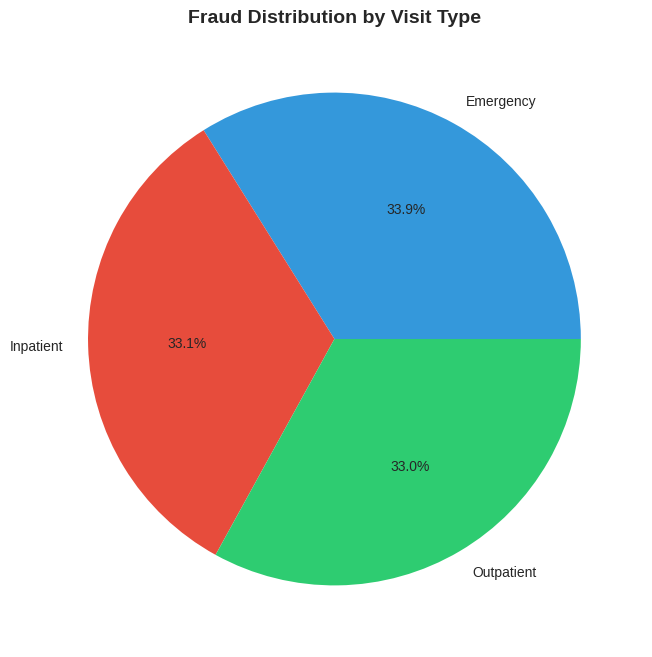


 Visit Type Risk Analysis:
Emergency: 8.43% fraud rate
Inpatient: 8.23% fraud rate
Outpatient: 8.21% fraud rate


In [17]:

plt.figure(figsize=(8, 8))

visit_fraud = df_viz.groupby('Visit_Type')['Is_Fraud'].mean()
plt.pie(visit_fraud.values, labels=visit_fraud.index, autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Fraud Distribution by Visit Type', fontsize=14, fontweight='bold')
plt.show()

print(f"\n Visit Type Risk Analysis:")
for visit_type, rate in visit_fraud.items():
    print(f"{visit_type}: {rate:.2%} fraud rate")

##  Claim Status Distribution

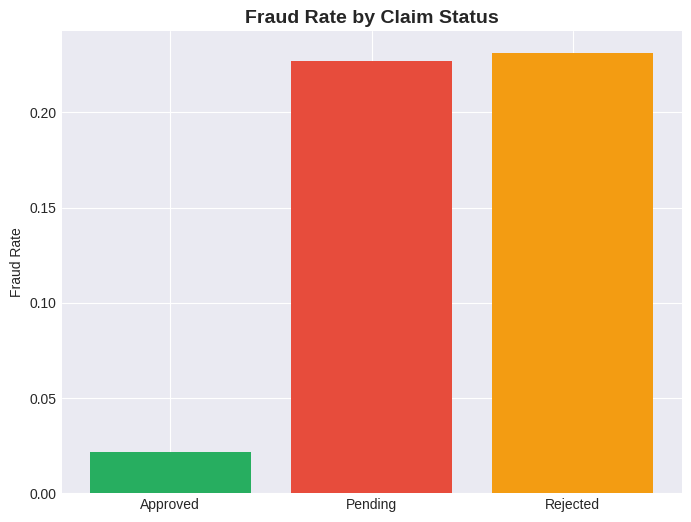


 Claim Status Analysis:
Approved: 2.17% fraud rate
Pending: 22.69% fraud rate
Rejected: 23.11% fraud rate


In [18]:

plt.figure(figsize=(8, 6))

status_fraud = df_viz.groupby('Claim_Status')['Is_Fraud'].mean()
plt.bar(range(len(status_fraud)), status_fraud.values, color=['#27ae60', '#e74c3c', '#f39c12'])
plt.xticks(range(len(status_fraud)), status_fraud.index)
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Claim Status', fontsize=14, fontweight='bold')
plt.show()

print(f"\n Claim Status Analysis:")
for status, rate in status_fraud.items():
    print(f"{status}: {rate:.2%} fraud rate")

## Prior Visits Analysis

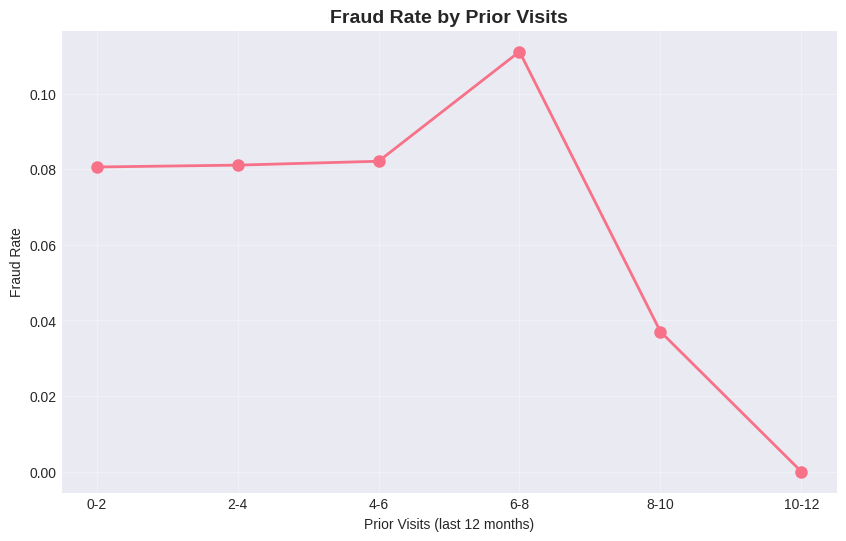


 Patient History Analysis:
Prior visits (0, 2]: 8.06% fraud rate
Prior visits (2, 4]: 8.11% fraud rate
Prior visits (4, 6]: 8.21% fraud rate
Prior visits (6, 8]: 11.11% fraud rate
Prior visits (8, 10]: 3.70% fraud rate
Prior visits (10, 12]: 0.00% fraud rate


In [19]:

plt.figure(figsize=(10, 6))

prior_bins = range(0, 13, 2)
df_viz['Prior_Visits_Bin'] = pd.cut(df_viz['Prior_Visits_12m'], bins=prior_bins)
prior_fraud = df_viz.groupby('Prior_Visits_Bin')['Is_Fraud'].mean()
plt.plot(range(len(prior_fraud)), prior_fraud.values, marker='o', linewidth=2, markersize=8)
plt.xticks(range(len(prior_fraud)), [f'{i}-{i+2}' for i in range(0, 12, 2)])
plt.xlabel('Prior Visits (last 12 months)')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Prior Visits', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n Patient History Analysis:")
for i, (bin_range, rate) in enumerate(prior_fraud.items()):
    print(f"Prior visits {bin_range}: {rate:.2%} fraud rate")

# Model

In [20]:
def prepare_modeling_data_no_leakage(df_engineered):
   
    
 

 
    
    # Select features for modeling
    exclude_cols = ['Claim_ID', 'Provider_ID', 'Diagnosis_Code', 'Procedure_Code',
                    'Claim_Submission_Date', 'Is_Fraud', 'Prior_Visits_Bin', 'Age_Group']
    
    # Get all numeric columns excluding the ones above
    feature_cols = [col for col in df_engineered.columns if col not in exclude_cols and 
                    df_engineered[col].dtype in ['int64', 'float64', 'bool']]
    
    X = df_engineered[feature_cols].copy()
    y = df_engineered['Is_Fraud'].copy()
    
    print(f"\nFeatures selected for modeling: {len(feature_cols)}")
    
    # Train-test split FIRST 
    print("\nSplitting data (stratified by fraud status)")
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Split again to get validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
    )
    
    print(f"\nTraining set: {X_train.shape[0]:,} samples")
    print(f"Validation set: {X_val.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples")
    print(f"Training fraud rate: {y_train.mean():.2%}")
    print(f"Validation fraud rate: {y_val.mean():.2%}")
    print(f"Test fraud rate: {y_test.mean():.2%}")
    
    # Handle missing values
    print("\nHandling missing values")
    numeric_imputer = SimpleImputer(strategy='median')
    X_train_imputed = pd.DataFrame(numeric_imputer.fit_transform(X_train), columns=X_train.columns)
    X_val_imputed = pd.DataFrame(numeric_imputer.transform(X_val), columns=X_val.columns)
    X_test_imputed = pd.DataFrame(numeric_imputer.transform(X_test), columns=X_test.columns)
    
    # Handle infinite values
    X_train_imputed = X_train_imputed.replace([np.inf, -np.inf], np.nan).fillna(X_train_imputed.median())
    X_val_imputed = X_val_imputed.replace([np.inf, -np.inf], np.nan).fillna(X_train_imputed.median())
    X_test_imputed = X_test_imputed.replace([np.inf, -np.inf], np.nan).fillna(X_train_imputed.median())
    
    # Scale features
    print("Scaling features")
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns)
    X_val_scaled = pd.DataFrame(scaler.transform(X_val_imputed), columns=X_val.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)
    
    # Handle imbalance with SMOTE
    print("\nHandling class imbalance with SMOTE")
    sm = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)
    print(f"After SMOTE - Training set: {X_train_resampled.shape[0]:,} samples")
    print(f"After SMOTE - Fraud rate: {y_train_resampled.mean():.2%}")
    
    # Save processed data
    processed_data = {
        'X_train': X_train_resampled,
        'X_val': X_val_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train_resampled,
        'y_val': y_val,
        'y_test': y_test,
        'feature_names': feature_cols,
        'scaler': scaler,
        'imputer': numeric_imputer
    }
    
    return processed_data

modeling_data = prepare_modeling_data_no_leakage(df_engineered)


Features selected for modeling: 39

Splitting data (stratified by fraud status)

Training set: 6,000 samples
Validation set: 2,000 samples
Test set: 2,000 samples
Training fraud rate: 8.28%
Validation fraud rate: 8.30%
Test fraud rate: 8.30%

Handling missing values
Scaling features

Handling class imbalance with SMOTE
After SMOTE - Training set: 11,006 samples
After SMOTE - Fraud rate: 50.00%


# TRAINING AND EVALUATION


Scale pos weight: 1.00
1. TRAINING RANDOM FOREST...

Random Forest - Validation Set:
ROC-AUC: 0.9994

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      1834
  Fraudulent       0.93      0.98      0.95       166

    accuracy                           0.99      2000
   macro avg       0.96      0.98      0.97      2000
weighted avg       0.99      0.99      0.99      2000

2. TRAINING XGBOOST...

XGBoost - Validation Set:
ROC-AUC: 0.9995

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1834
  Fraudulent       0.96      0.98      0.97       166

    accuracy                           0.99      2000
   macro avg       0.98      0.99      0.98      2000
weighted avg       1.00      0.99      1.00      2000

FINAL TEST SET RESULTS

 RANDOM FOREST - Test Set:
ROC-AUC: 0.9994
Classification Report:
              precision    recall  f1-sc

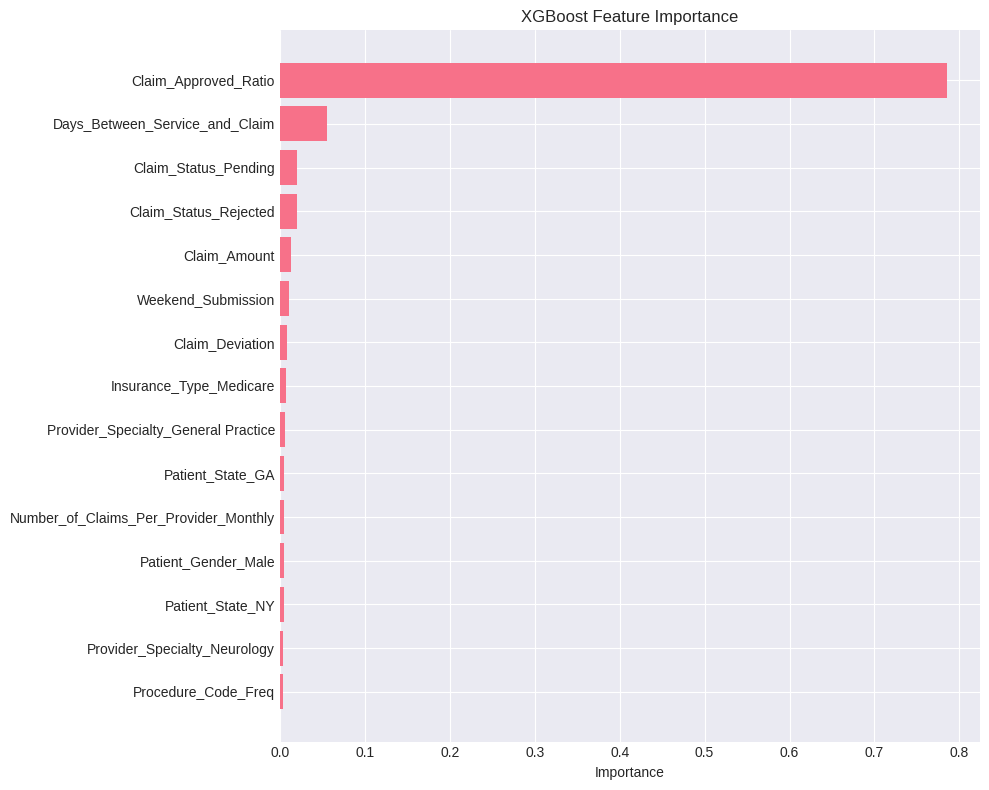

In [21]:
def train_and_evaluate_models(modeling_data):
    
    
   
    
    X_train = modeling_data['X_train']
    X_val = modeling_data['X_val']
    X_test = modeling_data['X_test']
    y_train = modeling_data['y_train']
    y_val = modeling_data['y_val']
    y_test = modeling_data['y_test']
    
    # Calculate scale_pos_weight for XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    print(f"\nScale pos weight: {scale_pos_weight:.2f}")
    
    # 1. Random Forest Baseline
   
    print("1. TRAINING RANDOM FOREST...")
  
    
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    
    # Predictions
    rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
    rf_val_pred = rf_model.predict(X_val)
    rf_test_prob = rf_model.predict_proba(X_test)[:, 1]
    rf_test_pred = rf_model.predict(X_test)
    
    # Evaluation
    print("\nRandom Forest - Validation Set:")
    print(f"ROC-AUC: {roc_auc_score(y_val, rf_val_prob):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_val, rf_val_pred, target_names=['Legitimate', 'Fraudulent']))
    
    # 2. XGBoost
    
    print("2. TRAINING XGBOOST...")
    
    
    xgb_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='auc',
        use_label_encoder=False
    )
    
    # Train with early stopping
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predictions
    xgb_val_prob = xgb_model.predict_proba(X_val)[:, 1]
    xgb_val_pred = xgb_model.predict(X_val)
    xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]
    xgb_test_pred = xgb_model.predict(X_test)
    
    # Evaluation
    print("\nXGBoost - Validation Set:")
    print(f"ROC-AUC: {roc_auc_score(y_val, xgb_val_prob):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_val, xgb_val_pred, target_names=['Legitimate', 'Fraudulent']))
    
    # Final Test Set Evaluation
    
    print("FINAL TEST SET RESULTS")
   
    
    print("\n RANDOM FOREST - Test Set:")
    print(f"ROC-AUC: {roc_auc_score(y_test, rf_test_prob):.4f}")
    print(f"Classification Report:")
    print(classification_report(y_test, rf_test_pred, target_names=['Legitimate', 'Fraudulent']))
    
    print("\n XGBOOST - Test Set:")
    print(f"ROC-AUC: {roc_auc_score(y_test, xgb_test_prob):.4f}")
    print(f"Classification Report:")
    print(classification_report(y_test, xgb_test_pred, target_names=['Legitimate', 'Fraudulent']))
    
    # Feature Importance
    
    print("FEATURE IMPORTANCE ANALYSIS")
    
    
    feature_importance = pd.DataFrame({
        'feature': modeling_data['feature_names'],
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    print("\nTop 15 Most Important Features:")
    print(feature_importance.to_string(index=False))
    
    # Plot feature importance
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(feature_importance)), feature_importance['importance'].values)
    plt.yticks(range(len(feature_importance)), feature_importance['feature'].values)
    plt.xlabel('Importance')
    plt.title('XGBoost Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return xgb_model, rf_model

models = train_and_evaluate_models(modeling_data)

In [22]:
import shap



xgb_model = models[0]


explainer = shap.TreeExplainer(xgb_model)

In [23]:
def explain_transaction(index, model, explainer, model_data):
 
    
    X = model_data['X_test']
    row = X.iloc[index:index+1]
    
    # Prediction probability
    prob = model.predict_proba(row)[0][1]
    
    # SHAP values
    shap_values = explainer.shap_values(row)[0]
    
    # Build explanation table
    explanation = pd.DataFrame({
        "feature": X.columns,
        "value": row.values[0],
        "shap_value": shap_values
    })
    
    explanation["abs_value"] = np.abs(explanation["shap_value"])
    explanation = explanation.sort_values("abs_value", ascending=False)
    
    # Split contributions
    top_risk = explanation[explanation["shap_value"] > 0].head(5)
    top_safe = explanation[explanation["shap_value"] < 0].head(5)
    
    # Risk level
    if prob >= 0.8:
        risk = "CRITICAL "
    elif prob >= 0.6:
        risk = "HIGH "
    elif prob >= 0.4:
        risk = "MEDIUM "
    else:
        risk = "LOW "
    
    # Output
   
    print(f" TRANSACTION ID: {index}")
    
    
    print(f" Fraud Probability: {prob:.4f}")
    print(f" Risk Level: {risk}")
    
    print("\n TOP FACTORS INCREASING FRAUD RISK:")
    print(top_risk[["feature", "value", "shap_value"]])
    
    print("\n TOP FACTORS DECREASING FRAUD RISK:")
    print(top_safe[["feature", "value", "shap_value"]])
    
    return {
        "probability": prob,
        "risk_level": risk,
        "explanation": explanation
    }

In [24]:
result = explain_transaction(
    index=10,
    model=models[0],
    explainer=explainer,
    model_data=modeling_data
)

 TRANSACTION ID: 10
 Fraud Probability: 0.0003
 Risk Level: LOW 

 TOP FACTORS INCREASING FRAUD RISK:
                           feature     value  shap_value
3   Days_Between_Service_and_Claim -1.354582    0.813163
36           Claim_Status_Rejected  2.156320    0.569398
17             Diagnosis_Code_Freq -1.628827    0.220743
7                 Prior_Visits_12m -0.017488    0.181598
37            Visit_Type_Inpatient -0.679697    0.108064

 TOP FACTORS DECREASING FRAUD RISK:
                                  feature     value  shap_value
9                    Claim_Approved_Ratio -0.690702   -7.526713
11                        Claim_Deviation -0.587645   -1.577039
25           Provider_Specialty_Neurology  2.358930   -0.252470
19                    Patient_Gender_Male -0.992693   -0.221896
4   Number_of_Claims_Per_Provider_Monthly -0.248837   -0.191421
